# Proyecto 3 - EDA de clientes

## Integrantes
- Daniel Fernando Salgado Santamaría
- Jairo Wladimir Jhayya Perlaza
- Luis Gabriel Salgado Santamaría
- Oscar Paul Naranjo Castro

**Fecha:** 2026-05-13  
**Notebook:** 02-jj-eda-clientes.ipynb

## Objetivo
Realizar el análisis exploratorio de clientes y su comportamiento a partir de las tablas:
- customers
- sessions
- events
- orders
- order_items
- products
- reviews

Este notebook construye una primera visión del cliente integrando variables demográficas, actividad de navegación, compras y reseñas, para preparar la siguiente etapa de feature engineering y clustering.

In [102]:
# Importa librerías necesarias para manejo de rutas, análisis de datos y visualización.
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
# Verifica el ejecutable de Python activo para confirmar que el notebook usa el entorno virtual correcto.
print("Python ejecutándose desde:")
print(sys.executable)

Python ejecutándose desde:
g:\ProyectosPython\proyecto3\.venv\Scripts\python.exe


In [104]:
# Configura opciones de visualización de pandas para mostrar mejor los resultados en notebook.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [105]:
# Configura el estilo visual global para obtener gráficos de alta calidad,
# legibles, profesionales y con colores vivos.
sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 400
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["font.weight"] = "regular"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"

In [106]:
# Define una paleta de colores vivos pero profesionales para mantener uniformidad visual.
PALETTE_VIVID = [
    "#0F766E",  # teal intenso
    "#2563EB",  # azul vivo
    "#DC2626",  # rojo elegante
    "#F59E0B",  # ámbar
    "#7C3AED",  # violeta controlado
    "#059669",  # verde fuerte
    "#EA580C",  # naranja profundo
    "#DB2777",  # magenta elegante
    "#0891B2",  # cyan fuerte
    "#65A30D",  # lima oscura
]

In [107]:
# Define rutas del proyecto de forma reproducible y crea carpetas necesarias si no existen.
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"

for path in [RAW_DIR, INTERIM_DIR, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("TABLES_DIR:", TABLES_DIR)

PROJECT_ROOT: G:\ProyectosPython\proyecto3\desarrollo3
RAW_DIR: G:\ProyectosPython\proyecto3\desarrollo3\data\raw
PROCESSED_DIR: G:\ProyectosPython\proyecto3\desarrollo3\data\processed
FIGURES_DIR: G:\ProyectosPython\proyecto3\desarrollo3\reports\figures
TABLES_DIR: G:\ProyectosPython\proyecto3\desarrollo3\reports\tables


In [108]:
# Crea una carpeta específica para guardar todas las figuras del EDA de clientes.
EDA_FIG_DIR = FIGURES_DIR / "eda_clientes"
EDA_FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_plot(filename):
    """
    Guarda la figura actual en alta resolución dentro de reports/figures/eda_clientes.
    """
    plt.savefig(EDA_FIG_DIR / filename, dpi=400, bbox_inches="tight", facecolor="white")

In [109]:
# Define funciones auxiliares para etiquetar barras verticales y horizontales con valores o porcentajes.
def annotate_bars(ax, fmt="{:.2f}", suffix="", fontsize=10, weight="bold"):
    """
    Añade etiquetas sobre cada barra vertical del gráfico.
    """
    for patch in ax.patches:
        height = patch.get_height()
        if pd.notnull(height):
            x = patch.get_x() + patch.get_width() / 2
            ax.annotate(
                fmt.format(height) + suffix,
                (x, height),
                ha="center",
                va="bottom",
                fontsize=fontsize,
                fontweight=weight,
                xytext=(0, 6),
                textcoords="offset points"
            )

def annotate_bars_horizontal(ax, fmt="{:.2f}", suffix="", fontsize=10, weight="bold"):
    """
    Añade etiquetas a cada barra horizontal del gráfico.
    """
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        if pd.notnull(width):
            ax.annotate(
                fmt.format(width) + suffix,
                (width, y),
                ha="left",
                va="center",
                fontsize=fontsize,
                fontweight=weight,
                xytext=(6, 0),
                textcoords="offset points"
            )

## Carga de datos

Se cargan nuevamente los archivos fuente desde `data/raw/` para que este notebook sea independiente, reproducible y reutilizable por cualquier integrante del equipo.

In [110]:
# Carga los datasets fuente desde la carpeta data/raw.
customers = pd.read_csv(RAW_DIR / "customers.csv")
sessions = pd.read_csv(RAW_DIR / "sessions.csv")
events = pd.read_csv(RAW_DIR / "events.csv")
orders = pd.read_csv(RAW_DIR / "orders.csv")
order_items = pd.read_csv(RAW_DIR / "order_items.csv")
products = pd.read_csv(RAW_DIR / "products.csv")
reviews = pd.read_csv(RAW_DIR / "reviews.csv")

In [111]:
# Agrupa los DataFrames en un diccionario para revisar rápidamente dimensiones y estructura general.
datasets = {
    "customers": customers,
    "sessions": sessions,
    "events": events,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "reviews": reviews,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (20000, 7)
sessions: (120000, 6)
events: (760958, 10)
orders: (33580, 10)
order_items: (59163, 5)
products: (1197, 6)
reviews: (10780, 6)


## Conversión inicial de tipos

Se convierten fechas a `datetime` y algunas variables categóricas a `category` para mejorar análisis temporal, eficiencia en memoria y legibilidad del dataset.

In [112]:
# Convierte columnas de fecha y hora a tipo datetime para facilitar análisis cronológicos.
customers["signup_date"] = pd.to_datetime(customers["signup_date"], errors="coerce")
sessions["start_time"] = pd.to_datetime(sessions["start_time"], errors="coerce")
events["timestamp"] = pd.to_datetime(events["timestamp"], errors="coerce")
orders["order_time"] = pd.to_datetime(orders["order_time"], errors="coerce")
reviews["review_time"] = pd.to_datetime(reviews["review_time"], errors="coerce")

In [113]:
# Convierte variables repetitivas de texto a tipo category para optimizar análisis y memoria.
customers["country"] = customers["country"].astype("category")

sessions["device"] = sessions["device"].astype("category")
sessions["source"] = sessions["source"].astype("category")
sessions["country"] = sessions["country"].astype("category")

events["event_type"] = events["event_type"].astype("category")
events["payment"] = events["payment"].astype("category")

orders["payment_method"] = orders["payment_method"].astype("category")
orders["country"] = orders["country"].astype("category")
orders["device"] = orders["device"].astype("category")
orders["source"] = orders["source"].astype("category")

products["category"] = products["category"].astype("category")

Las transformaciones anteriores aseguran tipos consistentes para el análisis temporal y categórico, y sientan las bases para la construcción de métricas agregadas a nivel de cliente en la siguiente sección.

## 1. Exploración básica de clientes

Se analizan variables centrales de `customers`:
- edad,
- aceptación de marketing,
- país,
- evolución temporal del registro.

In [114]:
# Muestra una vista inicial de la tabla customers.
customers.head()

,customer_id,name,email,country,age,signup_date,marketing_opt_in
0,1,Jennifer Salinas,nicholas59@example.org,JP,71,2020-09-04,True
1,2,Phillip Ramos,christinarubio@example.com,IN,26,2020-04-05,False
2,3,Dawn Fowler,jessica03@example.org,BR,21,2023-08-31,True
3,4,Mario Butler,paula27@example.org,FR,63,2022-06-30,True
4,5,Amber Brown,kevin85@example.net,BR,19,2022-07-22,True


In [115]:
# Resume estadísticamente la variable edad.
customers[["age"]].describe()

,age
count,"20,000.00"
mean,46.49
std,16.77
min,18.00
25%,32.00
50%,46.50
75%,61.00
max,75.00


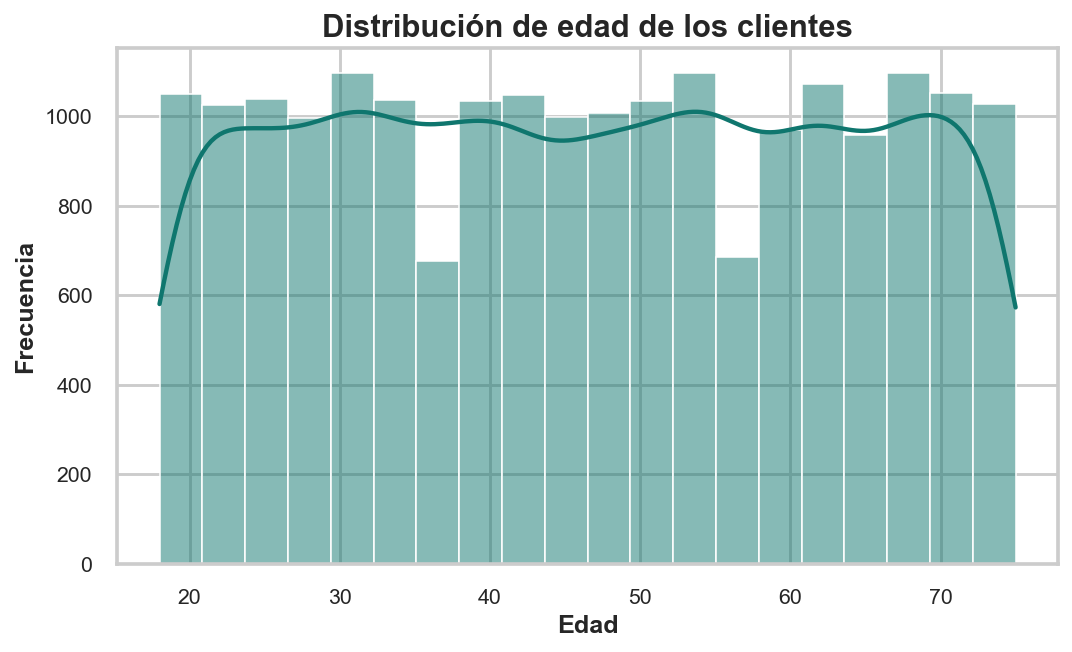

In [116]:
# Grafica la distribución de edad de los clientes.
plt.figure(figsize=(8, 5))

sns.histplot(
    customers["age"],
    bins=20,
    kde=True,
    color=PALETTE_VIVID[0],
    edgecolor="white",
    linewidth=0.8
)

plt.title("Distribución de edad de los clientes")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.tight_layout()
save_plot("distribucion_edad_clientes.png")
plt.show()

In [117]:
# Calcula la proporción y porcentaje de clientes según la aceptación de marketing.
marketing_counts = (
    customers["marketing_opt_in"]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

marketing_counts["percentage"] = (marketing_counts["proportion"] * 100).round(2)

print(marketing_counts)

   marketing_opt_in  proportion  percentage
0              True        0.56       55.55
1             False        0.44       44.45


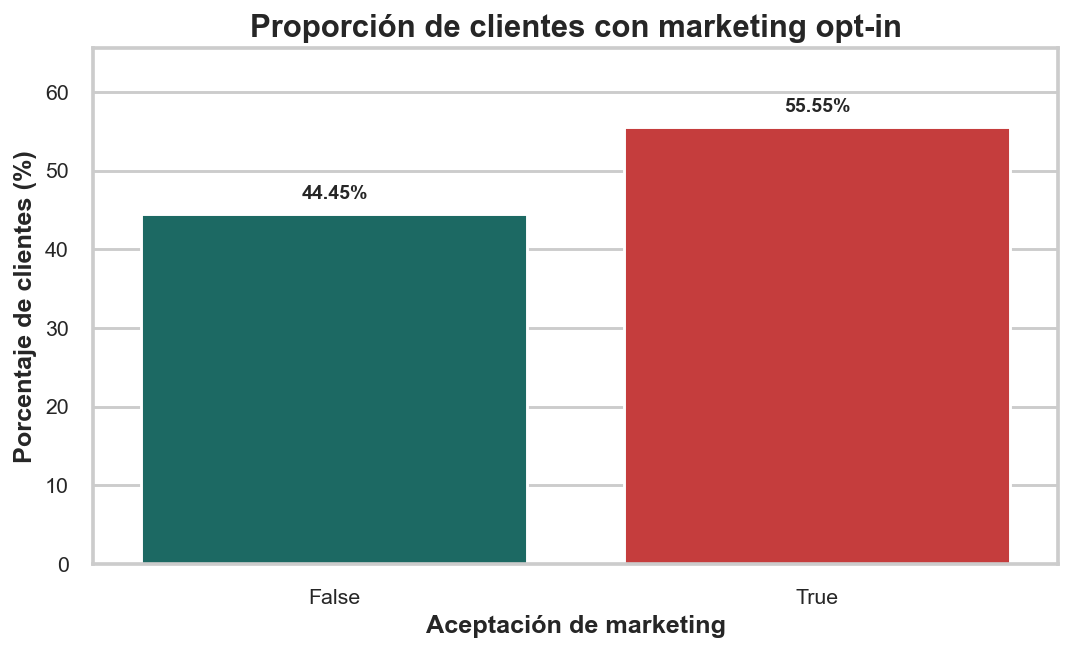

In [118]:
# Grafica la proporción de clientes con y sin marketing opt-in, mostrando el porcentaje sobre cada barra.
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=marketing_counts,
    x="marketing_opt_in",
    y="percentage",
    hue="marketing_opt_in",
    dodge=False,
    legend=False,
    palette=[PALETTE_VIVID[0], PALETTE_VIVID[2]]
)

annotate_bars(ax, fmt="{:.2f}", suffix="%")

plt.title("Proporción de clientes con marketing opt-in")
plt.xlabel("Aceptación de marketing")
plt.ylabel("Porcentaje de clientes (%)")
plt.ylim(0, marketing_counts["percentage"].max() * 1.18)
plt.tight_layout()
save_plot("proporcion_marketing_opt_in.png")
plt.show()

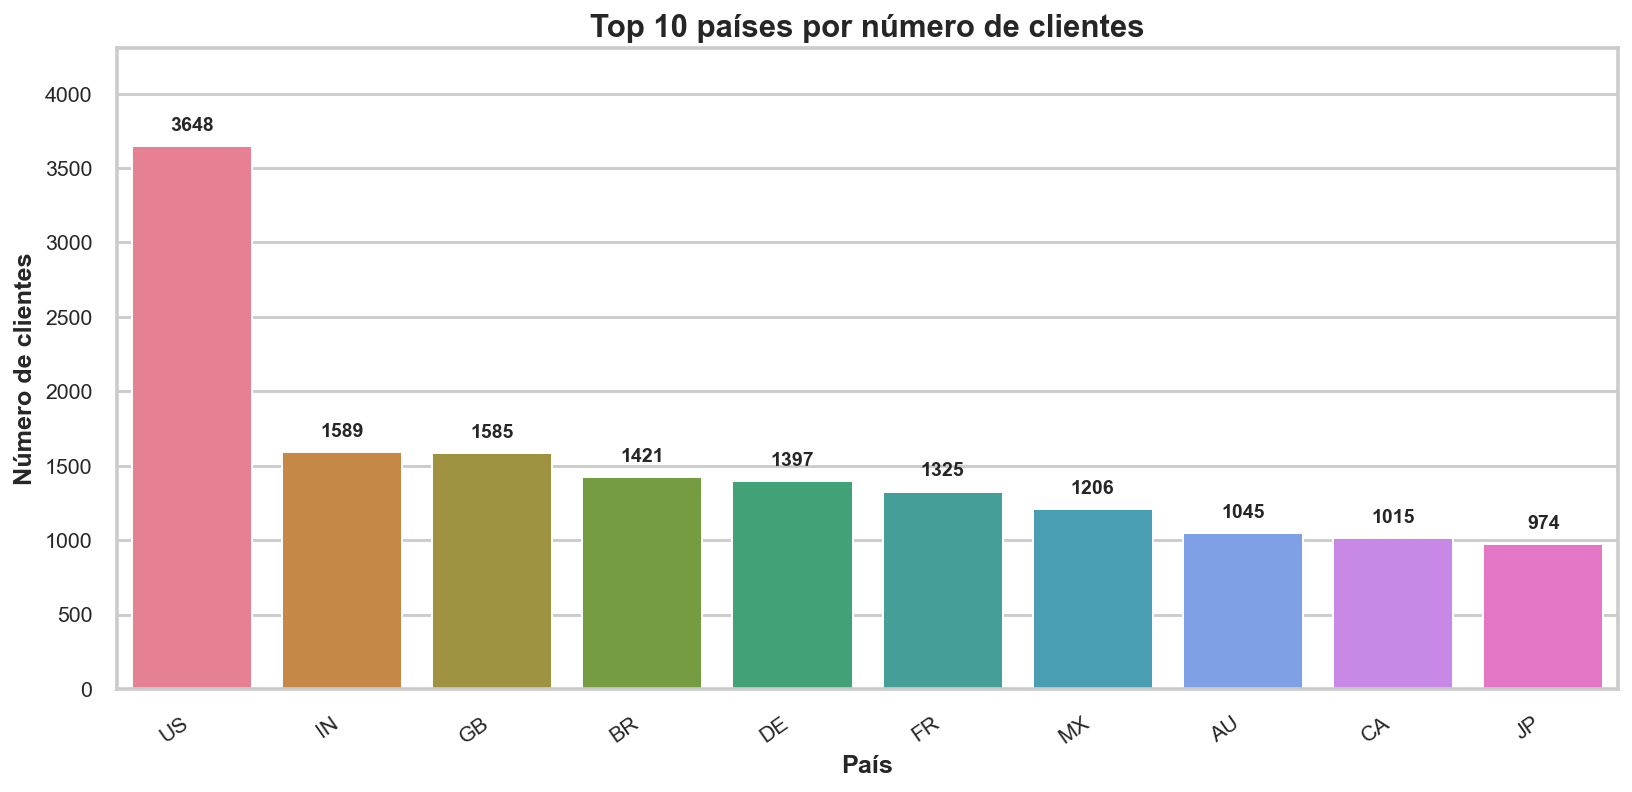

In [120]:
# Recalcula el top 10 de países por número de clientes.
country_counts = (
    customers["country"]
    .value_counts()
    .head(10)
    .rename_axis("country")
    .reset_index(name="customers_count")
)

# SOLUCIÓN DEFINITIVA:
# Convierte la columna country a string para evitar que seaborn herede categorías no usadas
# del dtype category original.
country_counts["country"] = country_counts["country"].astype(str)

# Crea una paleta viva y suficientemente larga, exactamente del tamaño necesario.
palette_countries = sns.color_palette("husl", n_colors=len(country_counts))

# Grafica el top 10 de países por número de clientes e incluye el valor sobre cada barra.
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=country_counts,
    x="country",
    y="customers_count",
    hue="country",
    dodge=False,
    legend=False,
    palette=palette_countries,
    edgecolor="white",
    linewidth=1
)

annotate_bars(ax, fmt="{:.0f}")

plt.title("Top 10 países por número de clientes")
plt.xlabel("País")
plt.ylabel("Número de clientes")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, country_counts["customers_count"].max() * 1.18)
plt.tight_layout()
save_plot("top_10_paises_clientes.png")
plt.show()

In [121]:
# Agrupa las altas de clientes por mes para analizar la evolución temporal del registro.
customers_by_date = (
    customers
    .groupby(customers["signup_date"].dt.to_period("M"))["customer_id"]
    .count()
    .rename("new_customers")
    .reset_index()
)

# Convierte el período mensual nuevamente a timestamp para graficar correctamente.
customers_by_date["signup_date"] = customers_by_date["signup_date"].dt.to_timestamp()

print(customers_by_date.head())

  signup_date  new_customers
0  2020-01-01            288
1  2020-02-01            261
2  2020-03-01            281
3  2020-04-01            255
4  2020-05-01            288


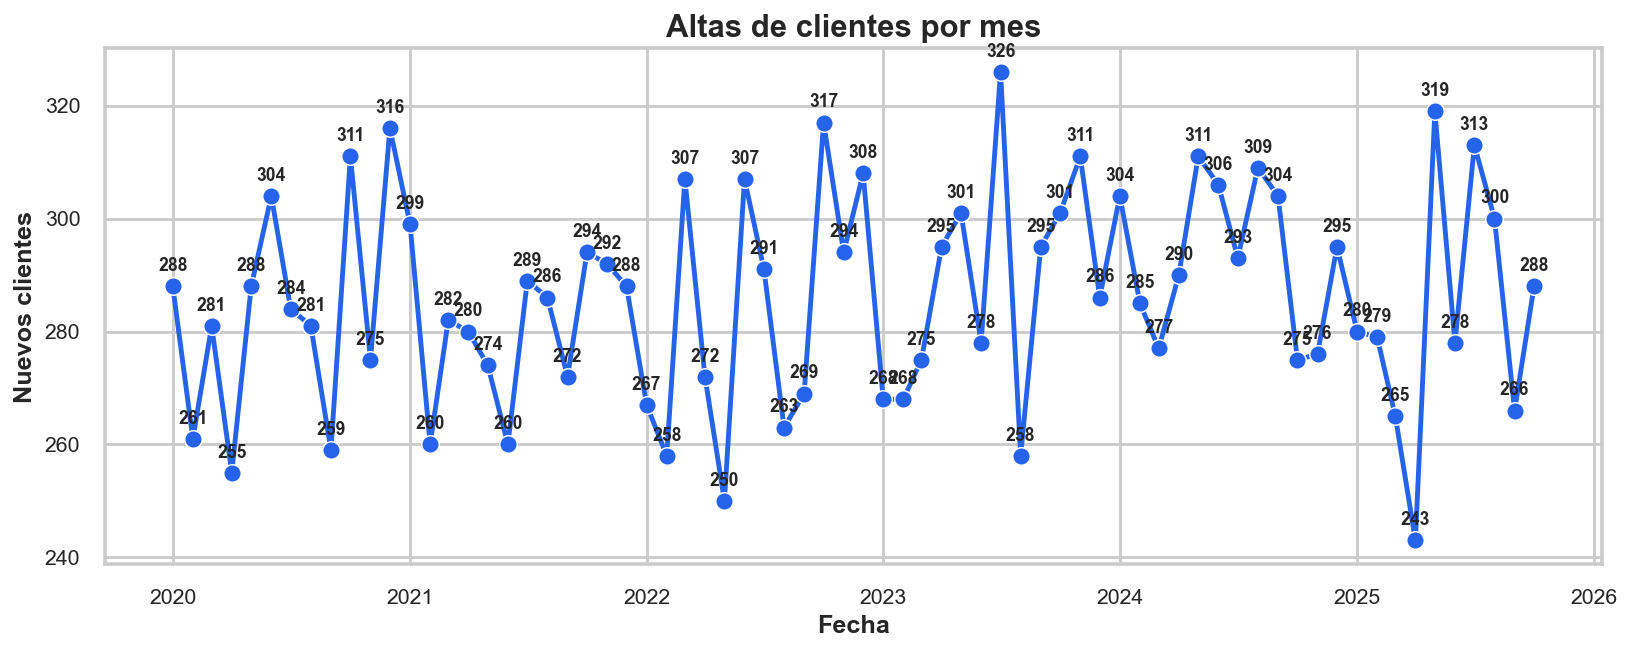

In [122]:
# Grafica las altas mensuales de clientes y etiqueta cada punto con su valor.
plt.figure(figsize=(12, 5))

ax = sns.lineplot(
    data=customers_by_date,
    x="signup_date",
    y="new_customers",
    marker="o",
    linewidth=2.5,
    color=PALETTE_VIVID[1]
)

for x, y in zip(customers_by_date["signup_date"], customers_by_date["new_customers"]):
    ax.annotate(
        f"{y:.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Altas de clientes por mes")
plt.xlabel("Fecha")
plt.ylabel("Nuevos clientes")
plt.tight_layout()
save_plot("altas_clientes_por_mes.png")
plt.show()

## 2. Construcción de métricas de comportamiento

Se generan métricas agregadas por cliente usando:
- sesiones,
- órdenes,
- reseñas.

Estas métricas permiten crear una tabla consolidada para segmentación posterior.

In [123]:
# Calcula el número de sesiones únicas por cliente.
sessions_per_customer = (
    sessions
    .groupby("customer_id")["session_id"]
    .nunique()
    .rename("n_sessions")
    .reset_index()
)

print(sessions_per_customer.head())

   customer_id  n_sessions
0            1           5
1            2           3
2            3           5
3            4           9
4            5           9


In [124]:
# Calcula métricas de compra por cliente: número de órdenes, ingreso total y ticket promedio.
orders_per_customer = (
    orders
    .groupby("customer_id")
    .agg(
        n_orders=("order_id", "nunique"),
        gross_revenue_usd=("total_usd", "sum"),
        avg_order_value_usd=("total_usd", "mean")
    )
    .reset_index()
)

print(orders_per_customer.head())

   customer_id  n_orders  gross_revenue_usd  avg_order_value_usd
0            1         2             115.39                57.69
1            2         2              68.52                34.26
2            3         1              66.72                66.72
3            4         2             279.86               139.93
4            5         3             271.29                90.43


In [125]:
# Vincula reseñas con clientes a través de order_id para calcular el número de reseñas por cliente.
reviews_with_customer = reviews.merge(
    orders[["order_id", "customer_id"]],
    on="order_id",
    how="left"
)

reviews_per_customer = (
    reviews_with_customer
    .groupby("customer_id")["review_id"]
    .nunique()
    .rename("n_reviews")
    .reset_index()
)

print(reviews_per_customer.head())

   customer_id  n_reviews
0            1          1
1            5          4
2            6          3
3           10          3
4           15          1


In [126]:
# Consolida variables demográficas y métricas de comportamiento en una sola tabla por cliente.
customer_features = (
    customers[["customer_id", "country", "age", "signup_date", "marketing_opt_in"]]
    .merge(sessions_per_customer, on="customer_id", how="left")
    .merge(orders_per_customer, on="customer_id", how="left")
    .merge(reviews_per_customer, on="customer_id", how="left")
)

# Reemplaza nulos con cero en variables de comportamiento para clientes sin actividad registrada.
behavior_cols = ["n_sessions", "n_orders", "gross_revenue_usd", "avg_order_value_usd", "n_reviews"]
customer_features[behavior_cols] = customer_features[behavior_cols].fillna(0)

print(customer_features.head())

   customer_id country  age signup_date  marketing_opt_in  n_sessions  n_orders  gross_revenue_usd  avg_order_value_usd  n_reviews
0            1      JP   71  2020-09-04              True        5.00      2.00             115.39                57.69       1.00
1            2      IN   26  2020-04-05             False        3.00      2.00              68.52                34.26       0.00
2            3      BR   21  2023-08-31              True        5.00      1.00              66.72                66.72       0.00
3            4      FR   63  2022-06-30              True        9.00      2.00             279.86               139.93       0.00
4            5      BR   19  2022-07-22              True        9.00      3.00             271.29                90.43       4.00


In [127]:
# Muestra un resumen estadístico de las métricas numéricas del cliente.
customer_features[
    ["age", "n_sessions", "n_orders", "gross_revenue_usd", "avg_order_value_usd", "n_reviews"]
].describe()

,age,n_sessions,n_orders,gross_revenue_usd,avg_order_value_usd,n_reviews
count,"20,000.00","20,000.00","20,000.00","20,000.00","20,000.00","20,000.00"
mean,46.49,6.00,1.68,224.66,109.14,0.54
std,16.77,2.47,1.29,262.27,122.42,1.11
min,18.00,0.00,0.00,0.00,0.00,0.00
25%,32.00,4.00,1.00,32.16,27.14,0.00
50%,46.50,6.00,2.00,145.39,82.58,0.00
75%,61.00,8.00,2.00,322.40,151.05,1.00
max,75.00,17.00,9.00,"3,026.42","2,680.64",10.00


Las métricas anteriores resumen el comportamiento de cada cliente en términos de edad, frecuencia de interacción con el sitio (`n_sessions`), volumen de compras (`n_orders` y `gross_revenue_usd`), gasto promedio por orden (`avg_order_value_usd`) y nivel de participación en reseñas (`n_reviews`). Esta tabla consolidada será el insumo principal para la etapa de clustering en el notebook `03-jj-clustering-clientes.ipynb`.

## 3. Distribución de actividad y valor del cliente

Se exploran:
- número de sesiones,
- número de órdenes,
- ingreso total,
- valor promedio por orden.

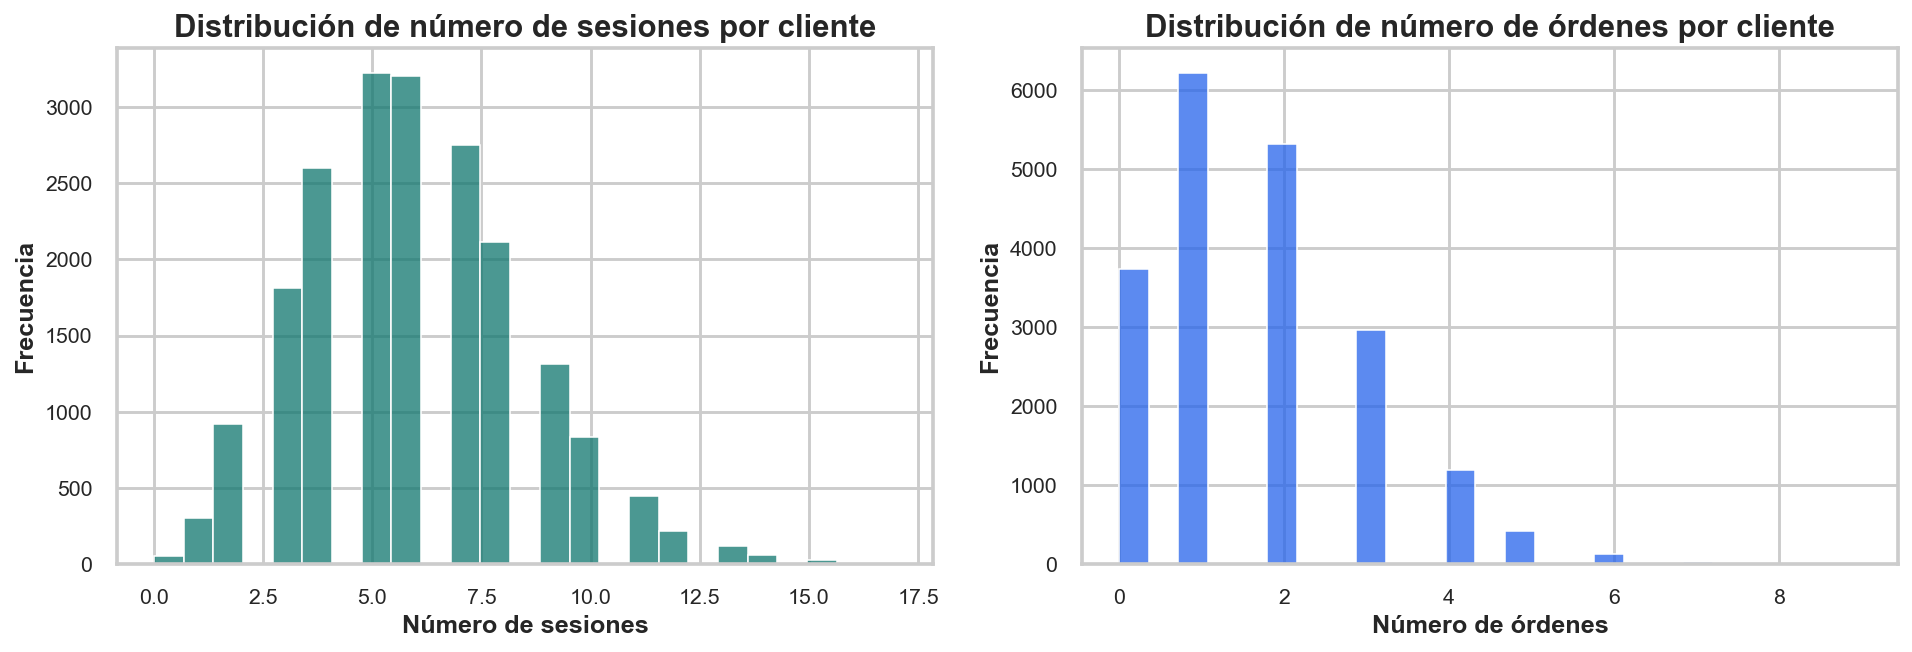

In [128]:
# Grafica la distribución de número de sesiones y número de órdenes por cliente.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    customer_features["n_sessions"],
    bins=25,
    ax=axes[0],
    color=PALETTE_VIVID[0],
    edgecolor="white",
    linewidth=0.8
)
axes[0].set_title("Distribución de número de sesiones por cliente")
axes[0].set_xlabel("Número de sesiones")
axes[0].set_ylabel("Frecuencia")

sns.histplot(
    customer_features["n_orders"],
    bins=25,
    ax=axes[1],
    color=PALETTE_VIVID[1],
    edgecolor="white",
    linewidth=0.8
)
axes[1].set_title("Distribución de número de órdenes por cliente")
axes[1].set_xlabel("Número de órdenes")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
save_plot("distribucion_sesiones_y_ordenes.png")
plt.show()

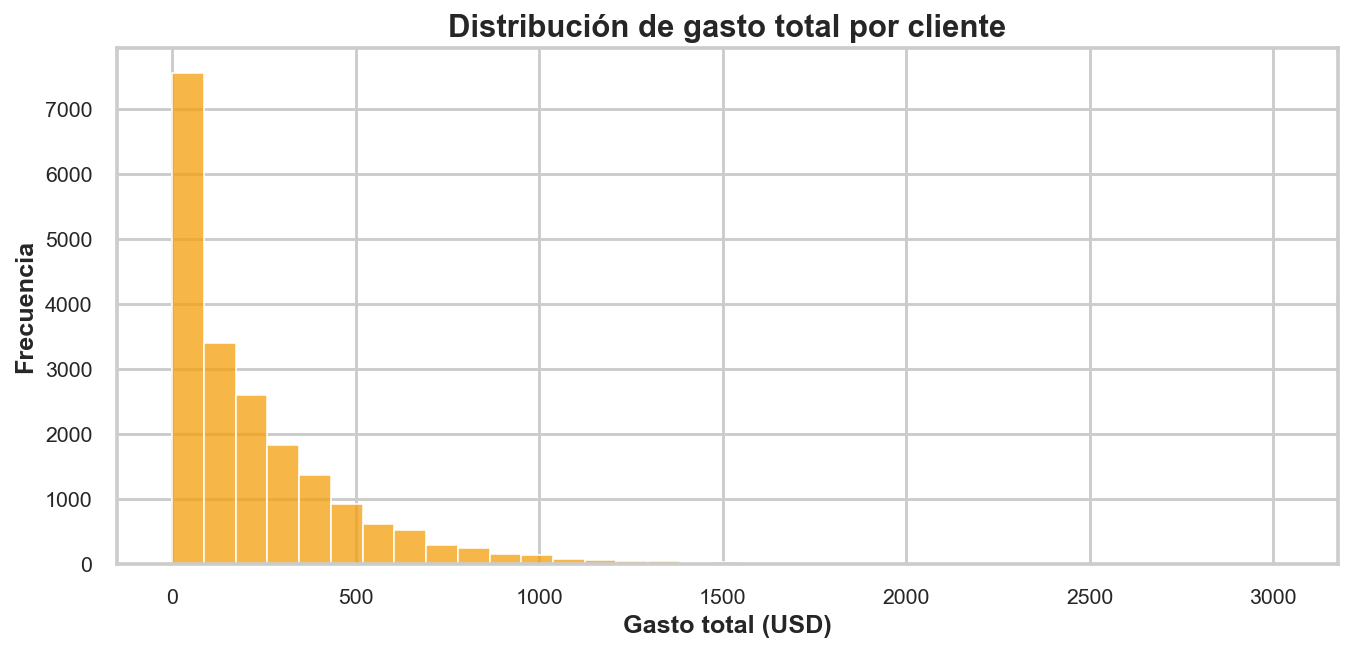

In [129]:
# Grafica la distribución del gasto total por cliente.
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_features["gross_revenue_usd"],
    bins=35,
    color=PALETTE_VIVID[3],
    edgecolor="white",
    linewidth=0.8
)

plt.title("Distribución de gasto total por cliente")
plt.xlabel("Gasto total (USD)")
plt.ylabel("Frecuencia")
plt.tight_layout()
save_plot("distribucion_gasto_total_cliente.png")
plt.show()

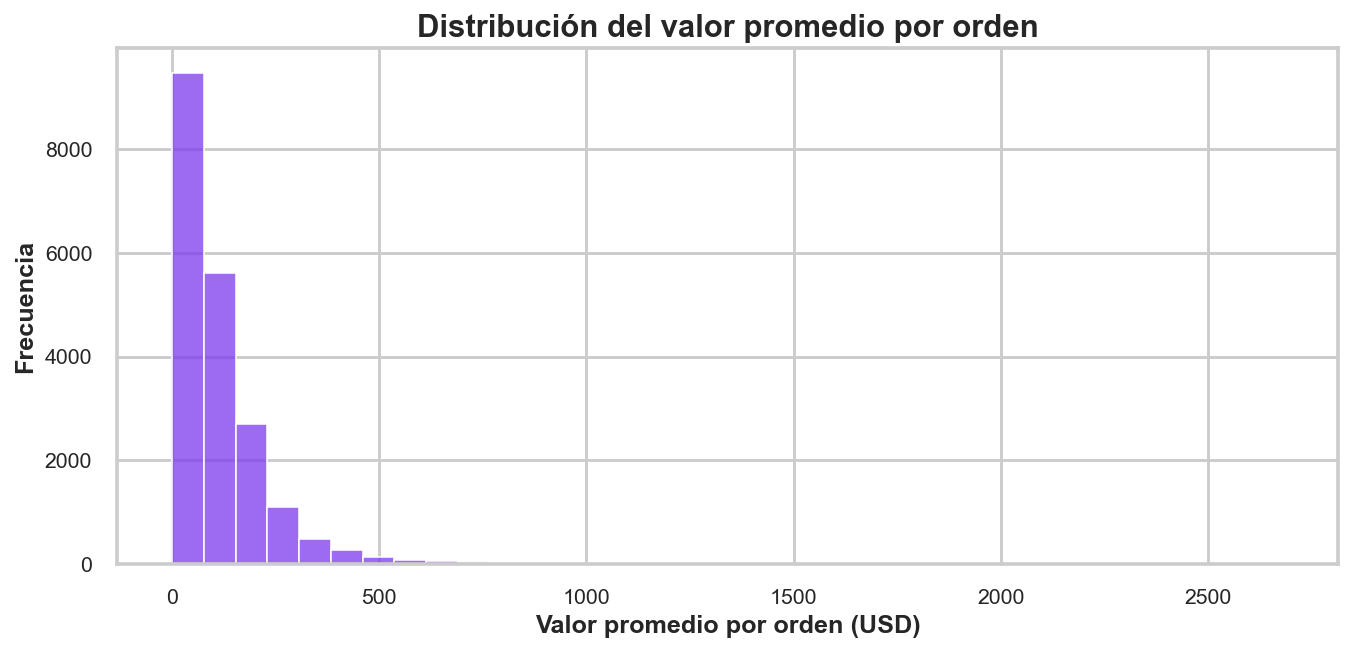

In [130]:
# Grafica la distribución del valor promedio por orden.
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_features["avg_order_value_usd"],
    bins=35,
    color=PALETTE_VIVID[4],
    edgecolor="white",
    linewidth=0.8
)

plt.title("Distribución del valor promedio por orden")
plt.xlabel("Valor promedio por orden (USD)")
plt.ylabel("Frecuencia")
plt.tight_layout()
save_plot("distribucion_ticket_promedio.png")
plt.show()

## 4. Relaciones entre variables numéricas

Se analiza la correlación entre métricas numéricas del cliente para detectar asociaciones iniciales útiles para la siguiente etapa de segmentación.

In [131]:
# Calcula la matriz de correlación entre variables numéricas clave del cliente.
numeric_cols = ["age", "n_sessions", "n_orders", "gross_revenue_usd", "avg_order_value_usd", "n_reviews"]
corr_matrix = customer_features[numeric_cols].corr()

print(corr_matrix)

                     age  n_sessions  n_orders  gross_revenue_usd  avg_order_value_usd  n_reviews
age                 1.00        0.01      0.01               0.00                 0.00       0.01
n_sessions          0.01        1.00      0.53               0.35                 0.14       0.20
n_orders            0.01        0.53      1.00               0.66                 0.26       0.38
gross_revenue_usd   0.00        0.35      0.66               1.00                 0.77       0.33
avg_order_value_usd 0.00        0.14      0.26               0.77                 1.00       0.17
n_reviews           0.01        0.20      0.38               0.33                 0.17       1.00


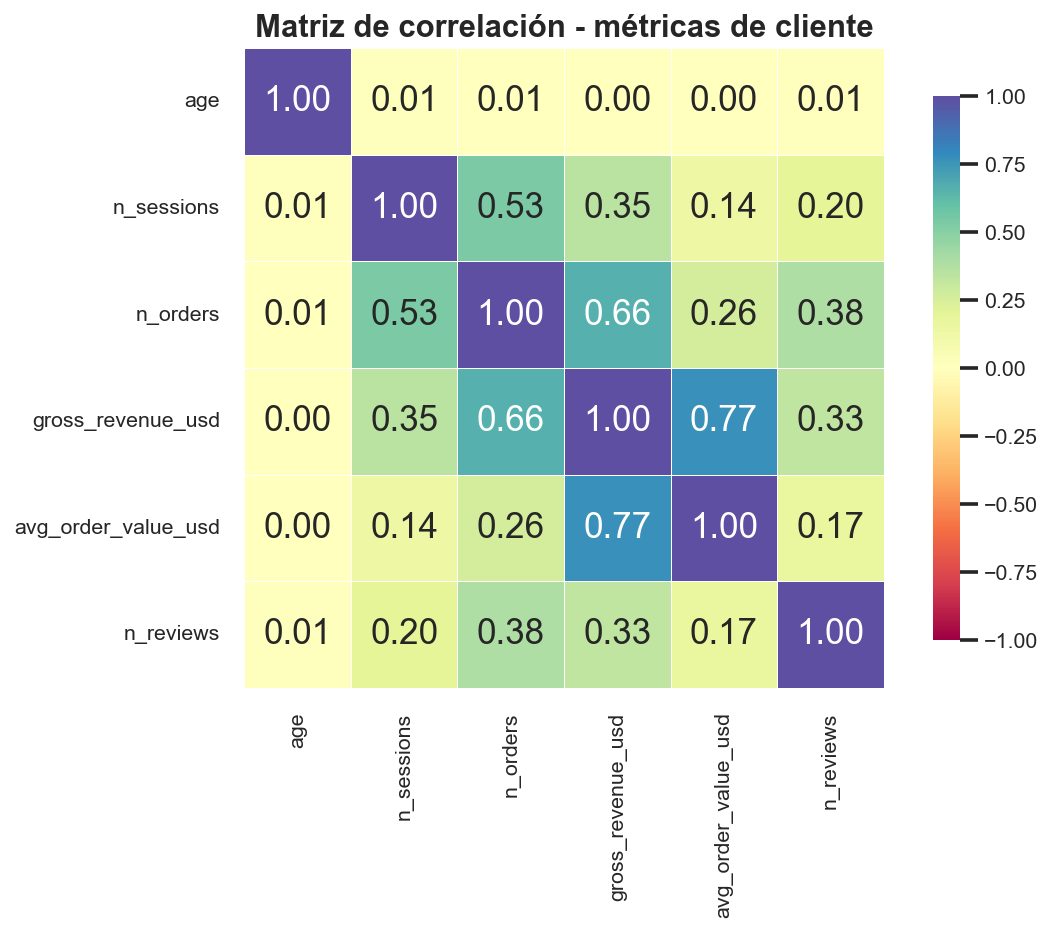

In [132]:
# Visualiza la matriz de correlación mediante un mapa de calor de alta calidad.
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Spectral",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.85}
)

plt.title("Matriz de correlación - métricas de cliente")
plt.tight_layout()
save_plot("matriz_correlacion_clientes.png")
plt.show()

## 5. Guardado de resultados

Se guardan:
- la tabla consolidada `customer_features.csv`,
- un resumen estadístico de variables numéricas,
- y todas las figuras generadas en alta resolución.

In [133]:
# Guarda la tabla consolidada de características de cliente para usarla en notebooks posteriores.
output_path = PROCESSED_DIR / "customer_features.csv"
customer_features.to_csv(output_path, index=False)

print(f"Tabla guardada en: {output_path}")

Tabla guardada en: G:\ProyectosPython\proyecto3\desarrollo3\data\processed\customer_features.csv


In [134]:
# Guarda un resumen estadístico de las variables numéricas del cliente en reports/tables.
customer_summary_table = customer_features[
    ["age", "n_sessions", "n_orders", "gross_revenue_usd", "avg_order_value_usd", "n_reviews"]
].describe().T

summary_output_path = TABLES_DIR / "customer_features_summary.csv"
customer_summary_table.to_csv(summary_output_path)

print(f"Resumen estadístico guardado en: {summary_output_path}")

Resumen estadístico guardado en: G:\ProyectosPython\proyecto3\desarrollo3\reports\tables\customer_features_summary.csv


## Interpretación final del EDA de clientes

El análisis exploratorio permitió integrar en una sola tabla (`customer_features`) la 
información demográfica básica del cliente junto con su comportamiento de navegación, 
compra y generación de reseñas. La edad de los clientes se distribuye de forma 
relativamente uniforme entre 18 y 75 años, con una mediana de 46 años, mientras que 
la actividad en la plataforma es heterogénea: la mayoría de clientes registra entre 4 
y 8 sesiones y entre 1 y 2 órdenes, pero existe una cola de usuarios con volúmenes de 
compra y gasto significativamente mayores.

Las métricas económicas muestran que tanto el ingreso total por cliente 
(`gross_revenue_usd`) como el ticket promedio (`avg_order_value_usd`) presentan una 
variabilidad elevada —con desviaciones estándar comparables a sus respectivas medias— 
lo que sugiere la presencia de segmentos con valor económico muy distinto. De forma 
complementaria, el número de reseñas (`n_reviews`) es bajo para la mayoría de clientes, 
con mediana en cero, indicando que la participación activa en evaluaciones es un 
comportamiento poco frecuente y, por tanto, potencialmente diferenciador entre grupos.

La estructura observada avala la decisión de utilizar estas seis variables numéricas 
como base para la segmentación posterior. La tabla `customer_features` resume de manera 
compacta los perfiles de uso, valor y engagement de los clientes, proporcionando un 
punto de partida sólido para aplicar K-Means y derivar segmentos accionables.

## Resultado de esta etapa

En este notebook se realizó el análisis exploratorio de clientes y se consolidó una tabla `customer_features.csv` que integra:
- datos demográficos,
- nivel de actividad,
- comportamiento de compra,
- y reseñas.

Además, se generaron figuras de alta calidad y tablas resumen reutilizables para el informe final y para la siguiente fase de clustering.